In [1]:
from google.cloud import bigquery

client = bigquery.Client(project="pythonbigq")
print("Connected!")

Connected!


In [2]:
query =""" 
SELECT 'hello!!!' AS message 
"""
result=client.query(query).result()
for row in result:
    print(row.message)

hello!!!


In [ ]:
#TOP 10 EVENTS BETWEEN START AND END DATE

query="""
SELECT event_name,COUNT(*) AS event_count
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201107'
GROUP BY event_name
ORDER BY event_count DESC
LIMIT 10
"""

result=client.query(query).result()
for row in result:
    print(f"{row.event_name} : {row.event_count:,}")

# df = client.query(query).to_dataframe()  # instead of .result()
# print(df.head())

page_view : 101,490
user_engagement : 91,167
scroll : 36,618
view_item : 33,746
session_start : 25,141
first_visit : 16,935
view_promotion : 16,761
view_search_results : 1,693
begin_checkout : 1,411
add_shipping_info : 1,409


In [24]:
query="""
SELECT event_date ,COUNT(DISTINCT event_date) AS count
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201107'
GROUP BY event_date
"""

result=client.query(query).result()
for row in result:
    print(f"{row.count}: {row.event_date:}")



1: 20201105
1: 20201101
1: 20201107
1: 20201102
1: 20201103
1: 20201106
1: 20201104


In [ ]:
#EVENTS THAT HAPPENED BTW THE START AND END DATE
query="""
SELECT DISTINCT event_name
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201107'

"""

result=client.query(query).result()
for row in result:
    print(row.event_name)

user_engagement
page_view
view_item
add_shipping_info
session_start
begin_checkout
first_visit
scroll
view_promotion
add_payment_info
view_search_results
click
select_promotion
view_item_list
purchase
add_to_cart


In [ ]:
#TOTAL REVENUE BTW START AND END DATE
query="""
SELECT  event_date, COUNT(*) AS purchase,
ROUND(SUM(ecommerce.purchase_revenue),2) AS total_revenue
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201107'
AND event_name='purchase'
GROUP BY event_date
ORDER BY total_revenue DESC

"""

result=client.query(query).result()
for row in result:
    print(f"{row.total_revenue}: {row.event_date}")

4789.0: 20201102
3438.0: 20201106
3313.0: 20201103
2531.0: 20201107
2197.0: 20201104
1792.0: 20201105
773.0: 20201101


In [ ]:
#NO.OF UNIQUE USERS WHO VISITED EACH DEVICE BTW S.D ,E.D
query="""
SELECT  COUNT(DISTINCT user_pseudo_id) as visitors,
        device.category AS device
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201107'
GROUP BY device
ORDER BY visitors DESC

"""

result=client.query(query).result()
for row in result:
    print(f"{row.device}: {row.visitors}")

desktop: 11630
mobile: 8000
tablet: 455


In [33]:
query="""
SELECT  COUNT(DISTINCT user_pseudo_id) as visitors,
        device.category AS device
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX = '20201101'
GROUP BY device
ORDER BY visitors DESC

"""

result=client.query(query).result()
for row in result:
    print(f"{row.device}: {row.visitors}")

desktop: 1373
mobile: 945
tablet: 47


In [34]:
table = client.get_table("bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_20201101")
for field in table.schema:
    print(f"{field.name} — {field.field_type}")

event_date — STRING
event_timestamp — INTEGER
event_name — STRING
event_params — RECORD
event_previous_timestamp — INTEGER
event_value_in_usd — FLOAT
event_bundle_sequence_id — INTEGER
event_server_timestamp_offset — INTEGER
user_id — STRING
user_pseudo_id — STRING
privacy_info — RECORD
user_properties — RECORD
user_first_touch_timestamp — INTEGER
user_ltv — RECORD
device — RECORD
geo — RECORD
app_info — RECORD
traffic_source — RECORD
stream_id — INTEGER
platform — STRING
event_dimensions — RECORD
ecommerce — RECORD
items — RECORD


In [40]:
query="""
SELECT COUNT(event_name) as count , event_name
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX = '20201101'
GROUP BY event_name
ORDER BY count
"""

result=client.query(query).result()
for row in result :
    print(f"{row.count} : {row.event_name}")

4 : add_to_cart
8 : view_item_list
11 : click
14 : purchase
57 : select_promotion
73 : add_payment_info
127 : begin_checkout
127 : add_shipping_info
194 : view_search_results
1263 : view_promotion
1946 : first_visit
2594 : session_start
3040 : scroll
3380 : view_item
8667 : user_engagement
9767 : page_view


In [ ]:
#USERS PER COUNTRY ON A PARTICULAR DATE

query="""
SELECT COUNT(DISTINCT user_pseudo_id) AS visitors,
geo.country AS country
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX = '20201101'
GROUP BY country
ORDER BY visitors
"""

result=client.query(query).result()
for row in result:
     print(f"{row.country} : {row.visitors}")

Bahrain : 1
Sri Lanka : 1
Jordan : 1
Costa Rica : 1
Serbia : 1
Romania : 1
Albania : 1
Latvia : 1
Ghana : 1
Kosovo : 1
Panama : 1
Azerbaijan : 1
Venezuela : 1
Bolivia : 1
Iceland : 1
Bosnia & Herzegovina : 1
Trinidad & Tobago : 1
Oman : 1
Kazakhstan : 1
Guatemala : 1
Ecuador : 1
Jamaica : 1
Hungary : 1
Kenya : 1
Dominican Republic : 1
Bangladesh : 2
Nigeria : 2
Tunisia : 2
Bulgaria : 2
Nepal : 2
Georgia : 2
Uruguay : 2
Paraguay : 2
Kuwait : 2
Iraq : 2
Malta : 2
South Africa : 3
Lebanon : 3
Norway : 3
Cambodia : 3
El Salvador : 3
Finland : 3
Puerto Rico : 3
Hong Kong : 4
Slovakia : 4
Egypt : 4
Ukraine : 4
Lithuania : 4
Austria : 4
New Zealand : 4
Saudi Arabia : 4
Chile : 5
Slovenia : 5
Colombia : 5
Czechia : 7
Argentina : 7
Denmark : 8
Switzerland : 8
Vietnam : 8
Peru : 9
Thailand : 9
Belgium : 10
Greece : 10
Israel : 11
United Arab Emirates : 11
Malaysia : 11
Sweden : 12
Poland : 13
Portugal : 14
Philippines : 14
Ireland : 15
Pakistan : 15
(not set) : 16
Brazil : 16
Russia : 18
Austral

In [ ]:
#percentage of visits came from mobile vs desktop vs tablet ON A DAY

query="""
WITH temp AS (
SELECT COUNT(user_pseudo_id) as total_visitors
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX = '20201101'
)


SELECT  COUNT(user_pseudo_id) as visitors ,
        device.category AS device,(COUNT(user_pseudo_id)  * 100.0) / (MAX(total_visitors)) AS percentage
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*` CROSS JOIN temp
WHERE device.category IN ('mobile','desktop','tablet') AND _TABLE_SUFFIX = '20201101'
GROUP BY device
ORDER BY percentage DESC

"""

result=client.query(query).result()
for row in result:
    print(f"{row.device}: {row.percentage}")





desktop: 58.27257610642108
mobile: 40.14134049629061
tablet: 1.586083397288309


In [43]:
query="""
SELECT DISTINCT device.category as d
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX = '20201101'

"""

result=client.query(query).result()
for row in result:
    print(row.d)

desktop
mobile
tablet


In [ ]:

#NO.OF PURCHASE IN A PARTICULAR MONTH
query="""
SELECT event_date , COUNT(*) as purchases 
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX LIKE '202011%' AND event_name='purchase'
GROUP BY event_date
ORDER BY purchases DESC


"""

df=client.query(query).to_dataframe()
print(df)

/home/keerthana/Desktop/pythonBigQ/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   event_date  purchases
0    20201124        147
1    20201130        141
2    20201123        141
3    20201120        118
4    20201125        108
5    20201117         98
6    20201127         97
7    20201119         84
8    20201113         79
9    20201128         78
10   20201116         69
11   20201118         68
12   20201121         68
13   20201110         64
14   20201111         64
15   20201122         60
16   20201106         58
17   20201126         57
18   20201112         54
19   20201109         52
20   20201129         51
21   20201102         49
22   20201103         49
23   20201104         46
24   20201108         32
25   20201107         31
26   20201114         30
27   20201105         26
28   20201115         21
29   20201101         14


In [ ]:
 # TOP 10 average revenue per purchase per day OF A PARTICULAR MONTH#
query="""
SELECT event_date, AVG(ecommerce.purchase_revenue) as avg,COUNT(*) AS purchases
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX LIKE '202011%' AND event_name='purchase'
GROUP BY event_date
ORDER BY avg DESC
LIMIT 10
"""

result=client.query(query).result()
for row in result:
    print(f"{row.event_date}: {row.avg} :{row.purchases}")


20201108: 117.5 :32
20201102: 97.73469387755104 :49
20201128: 89.35714285714286 :78
20201130: 88.16176470588238 :141
20201120: 82.9433962264151 :118
20201107: 81.64516129032259 :31
20201125: 78.84466019417475 :108
20201129: 78.81632653061227 :51
20201114: 77.93333333333334 :30
20201126: 76.53703703703704 :57


In [ ]:
#conversion rate? (users who purchased / total users) OF A MONTH

query="""
WITH temp AS (
SELECT event_date,COUNT(DISTINCT user_pseudo_id) as total_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX LIKE '202011%'
GROUP BY event_date
)


SELECT  COUNT(DISTINCT user_pseudo_id) as users ,e.event_date,
        ROUND(COUNT(DISTINCT user_pseudo_id)*100.0 /MAX(total_users),2) as con_rate
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`AS e 
INNER JOIN temp AS t ON t.event_date = e.event_date
WHERE _TABLE_SUFFIX LIKE '202011%' AND event_name ='purchase'
GROUP BY e.event_date
ORDER BY e.event_date

"""

result=client.query(query).result()
for row in result:
    print(f"{row.event_date}: {row.con_rate}")





20201101: 0.55
20201102: 1.2
20201103: 0.99
20201104: 0.8
20201105: 0.79
20201106: 1.71
20201107: 1.4
20201108: 1.62
20201109: 1.43
20201110: 1.96
20201111: 1.91
20201112: 1.6
20201113: 2.31
20201114: 1.4
20201115: 1.07
20201116: 2.2
20201117: 2.46
20201118: 1.4
20201119: 1.23
20201120: 1.84
20201121: 1.27
20201122: 1.23
20201123: 1.81
20201124: 2.51
20201125: 2.11
20201126: 1.49
20201127: 2.53
20201128: 2.43
20201129: 1.66
20201130: 3.17


/home/keerthana/Desktop/pythonBigQ/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


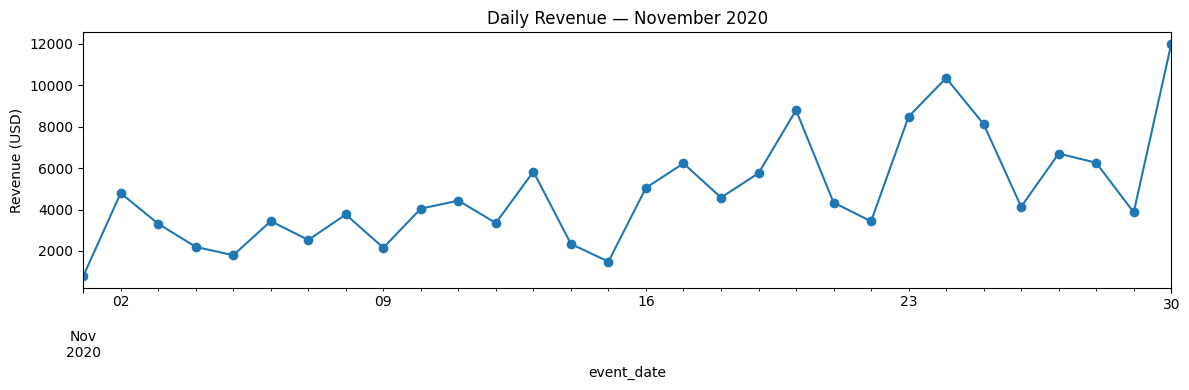

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

query = """
SELECT
    event_date,
    ROUND(SUM(ecommerce.purchase_revenue), 2) AS revenue
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE
    _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
    AND event_name = 'purchase'
GROUP BY event_date
ORDER BY event_date
"""

df = client.query(query).to_dataframe()
df['event_date'] = pd.to_datetime(df['event_date'], format='%Y%m%d')
df.set_index('event_date', inplace=True)

df['revenue'].plot(
    figsize=(12, 4),
    title='Daily Revenue — November 2020',
    ylabel='Revenue (USD)',
    marker='o'
)
plt.tight_layout()
plt.show()